In [1]:
# 1. தேவையான லைப்ரரிகளை இறக்குமதி செய்தல்
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 2. மாதிரிக்கான டேட்டாசெட் உருவாக்குதல் (அல்லது pd.read_csv('Churn_Modelling.csv'))
np.random.seed(42)
n_samples = 1000

data = {
    'CreditScore': np.random.randint(500, 850, n_samples),
    'Geography': np.random.choice(
        ['France', 'Spain', 'Germany'], n_samples, p=[0.5, 0.25, 0.25]
    ),
    'Gender': np.random.choice(['Female', 'Male'], n_samples),
    'Age': np.random.randint(18, 70, n_samples),
    'Tenure': np.random.randint(0, 10, n_samples),
    'Balance': np.random.uniform(0, 200000, n_samples),
    'NumOfProducts': np.random.choice([1, 2, 3, 4], n_samples, p=[
        0.5,
        0.4,
        0.08,
        0.02,
    ]),
    'HasCrCard': np.random.choice([0, 1], n_samples),
    'IsActiveMember': np.random.choice([0, 1], n_samples, p=[0.4, 0.6]),
    'EstimatedSalary': np.random.uniform(20000, 150000, n_samples),
    # Churn: 1 = வெளியேறினார், 0 = தொடர்ந்து இருக்கிறார்
    'Exited': np.random.choice([0, 1], n_samples, p=[0.8, 0.2]),
}

df = pd.DataFrame(data)
print('--- Dataset Preview ---')
print(df.head())

# 3. Data Preprocessing (தரவுச் சீரமைப்பு)
# எழுத்து வடிவில் உள்ளவற்றை எண்களாக மாற்றுதல் (Encoding)
le_geo = LabelEncoder()
le_gender = LabelEncoder()

df['Geography'] = le_geo.fit_transform(df['Geography'])
df['Gender'] = le_gender.fit_transform(df['Gender'])

# Features (X) மற்றும் Target (y) பிரித்தல்
X = df.drop('Exited', axis=1)
y = df['Exited']

# Train & Test ஆகப் பிரித்தல் (80% பயிற்சிக்கு, 20% சோதனைக்கு)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling (மதிப்புகளை ஒரே அளவுக்குக் கொண்டு வருதல்)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Machine Learning Model Training (Random Forest)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Model Evaluation (மதிப்பீடு)
y_pred = model.predict(X_test_scaled)

print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred))

# 6. Feature Importance (எந்தக் காரணி அதிக தாக்கம் செலுத்துகிறது?)
importance = pd.Series(
    model.feature_importances_, index=X.columns
).sort_values(ascending=False)
print('\n--- Top Factors Influencing Churn ---')
print(importance.head(5))

--- Dataset Preview ---
   CreditScore Geography  Gender  Age  Tenure        Balance  NumOfProducts  \
0          602   Germany    Male   31       6  152578.667111              1   
1          848   Germany  Female   28       0    9090.500087              2   
2          770   Germany    Male   52       2  129320.088790              2   
3          606   Germany  Female   58       3   45348.236881              2   
4          571    France  Female   31       3  134006.507562              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1     95961.565129       0  
1          1               0     86108.566131       0  
2          1               1     61398.755685       1  
3          0               1    115020.644671       0  
4          0               1     57403.396484       0  

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.80      0.99      0.89       160
           1       0.00  

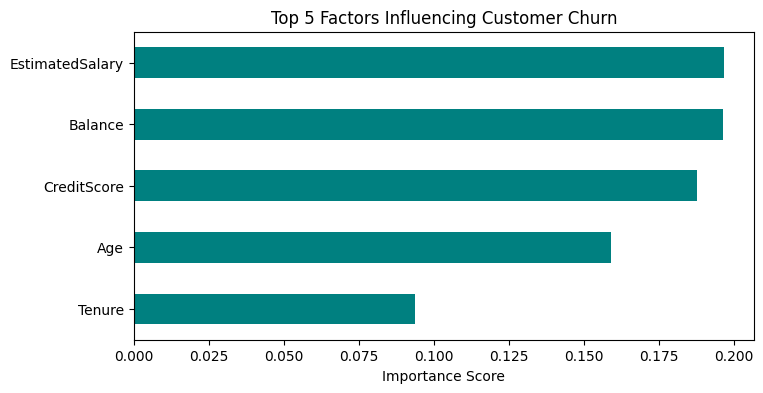

In [2]:
# வரைபடம் மூலம் முக்கிய காரணிகளைக் காட்டுதல்
plt.figure(figsize=(8, 4))
importance.head(5).plot(kind='barh', color='teal')
plt.title('Top 5 Factors Influencing Customer Churn')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()